# Sleep Oscillations: Slow Waves & Spindles

Deep sleep (NREM) is defined by two characteristic oscillations that can be directly recorded with iEEG. This notebook covers:

1. What slow waves are and how to detect them
2. What sleep spindles are and how to detect them
3. Why iEEG reveals aspects of these oscillations invisible to scalp EEG
4. Quantifying oscillation properties across channels

## The two pillars of NREM sleep

During deep sleep (stages N2 and N3), the brain produces two highly stereotyped oscillations:

### Slow waves (0.5–2 Hz)
Large-amplitude (up to 1000 µV in iEEG) sinusoidal waves where the cortex alternates between two states:
- **Down state (hyperpolarisation)**: Neurons go briefly silent. The iEEG shows a large negative deflection.
- **Up state (depolarisation)**: Neurons fire together. The iEEG shows a positive peak.

This is the brain essentially 'rebooting' — thought to be critical for memory consolidation and synaptic homeostasis.

### Sleep spindles (12–15 Hz, 'sigma band')
Brief bursts (0.5–3 seconds) of waxing-and-waning oscillations in the 12–15 Hz range. They look like a spindle shape in the time series. Spindles are generated by thalamocortical circuits and are thought to play a key role in transferring memories from hippocampus to cortex.

iEEG gives us a huge advantage here: we can detect slow waves and spindles independently in different brain regions, whereas scalp EEG only shows the global average.

In [1]:
!pip install mne

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks

# Load and preprocess (quick version of Notebook 2 pipeline)
homepath = '/content/drive/MyDrive/iEEG_course_UCL'
vhdr_path = Path(homepath) / 'ds003498/sub-02/ses-interictalsleep/ieeg/sub-02_ses-interictalsleep_run-01_ieeg.vhdr'

raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)
raw.filter(l_freq=0.5, h_freq=200.0, verbose=False)
raw.notch_filter(freqs=[50, 100, 150, 200], verbose=False)

good_chs = [ch for ch in raw.ch_names if ch not in raw.info['bads']]
ch_name  = good_chs[0]
fs       = raw.info['sfreq']

print(f"Using channel: {ch_name}  |  Sampling rate: {fs} Hz")

Using channel: AHL1  |  Sampling rate: 2000.0 Hz


## Part 1: Detecting slow waves

The standard approach to detect slow waves has two steps:

1. Band-pass filter the signal to the slow-wave range (0.5–2 Hz)
2. Find large negative peaks (down states) in the filtered signal

A valid slow wave must:
- Have a peak-to-peak amplitude above a threshold (typically 75 µV on scalp EEG; much higher in iEEG)
- Have a duration consistent with 0.5–2 Hz (i.e., the full cycle lasts 0.5–2 seconds)

In [3]:
# Extract the slow-wave band (0.5–2 Hz)
raw_sw = raw.copy().filter(l_freq=0.5, h_freq=2.0, verbose=False)

signal_sw = raw_sw.get_data(picks=[ch_name])[0] * 1e6  # µV
times      = raw.times

In [4]:
# Find negative peaks (down states)
# find_peaks works on positive peaks, so we invert the signal
amplitude_threshold = np.percentile(np.abs(signal_sw), 75)  # top 25% of amplitudes
min_distance = int(0.5 * fs)   # at least 0.5 seconds between peaks (slow waves are 0.5–2 Hz)

down_state_indices, _ = find_peaks(-signal_sw,
                                    height=amplitude_threshold,
                                    distance=min_distance)

print(f"Amplitude threshold: {amplitude_threshold:.0f} µV")
print(f"Slow waves detected: {len(down_state_indices)}")
print(f"Recording duration : {times[-1]/60:.1f} minutes")
print(f"Rate               : {len(down_state_indices) / (times[-1]/60):.1f} slow waves per minute")

Amplitude threshold: 125 µV
Slow waves detected: 180
Recording duration : 5.0 minutes
Rate               : 36.0 slow waves per minute


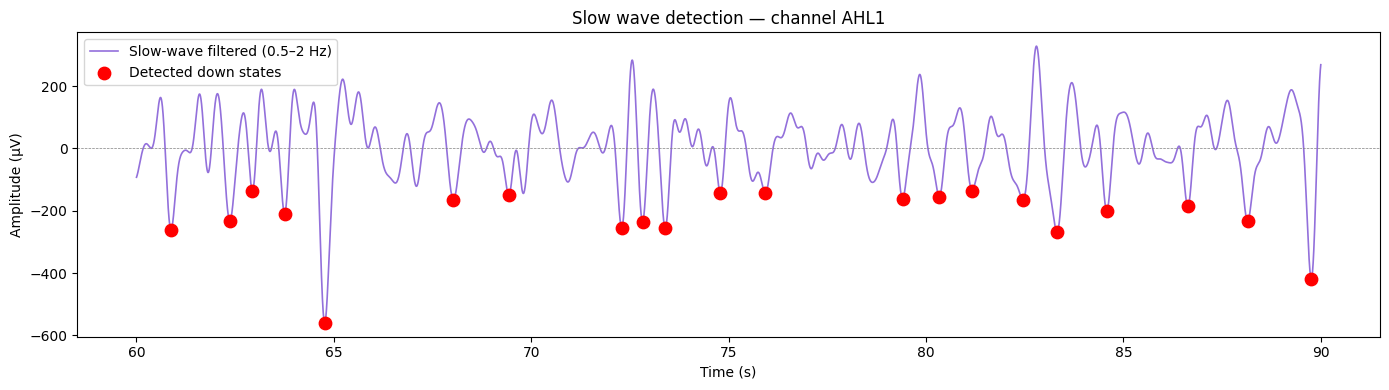

In [5]:
# Plot 30 seconds of signal with detected slow waves marked
T_START, T_END = 60, 90
mask = (times >= T_START) & (times <= T_END)
sw_in_window = down_state_indices[(times[down_state_indices] >= T_START) &
                                   (times[down_state_indices] <= T_END)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(times[mask], signal_sw[mask], color='mediumpurple', lw=1.2, label='Slow-wave filtered (0.5–2 Hz)')
ax.scatter(times[sw_in_window], signal_sw[sw_in_window],
           color='red', zorder=5, s=80, label='Detected down states')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title(f'Slow wave detection — channel {ch_name}')
ax.legend()
plt.tight_layout()
plt.show()

## Averaging around detected slow waves

A powerful technique is to take a small time window around each detected slow wave and average them together. This is called an **event-triggered average**. Noise that is random will cancel out, while the slow wave shape — which is consistent across events — will be preserved.

This reveals the true slow-wave waveform: a negative trough (down state) followed by a positive peak (up state).

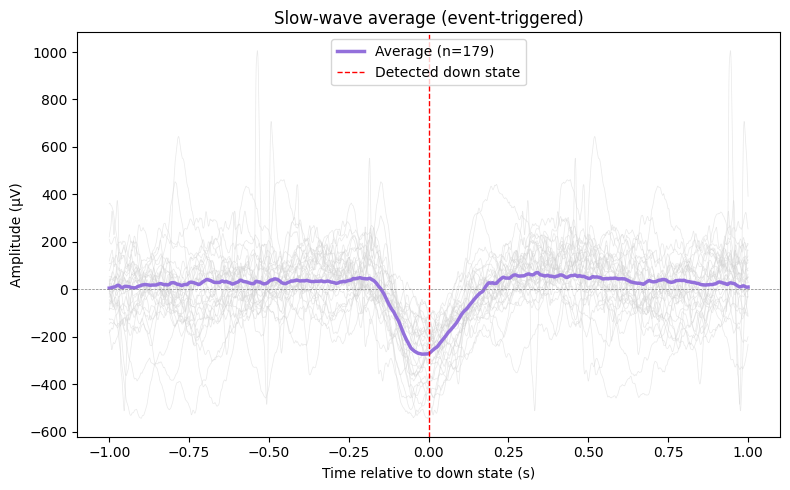

In [6]:
# Extract ±1 second around each detected down state and average
half_win = int(1.0 * fs)  # 1 second on each side
epochs = []

raw_signal = raw.get_data(picks=[ch_name])[0] * 1e6  # unfiltered signal in µV

for idx in down_state_indices:
    start, end = idx - half_win, idx + half_win
    if start >= 0 and end < len(raw_signal):
        epochs.append(raw_signal[start:end])

epochs = np.array(epochs)
epoch_times = np.linspace(-1, 1, epochs.shape[1])

fig, ax = plt.subplots(figsize=(8, 5))
# Plot individual epochs in light gray
for epoch in epochs[:30]:  # first 30
    ax.plot(epoch_times, epoch, color='lightgray', lw=0.5, alpha=0.5)
# Plot the average on top
ax.plot(epoch_times, epochs.mean(axis=0), color='mediumpurple', lw=2.5, label=f'Average (n={len(epochs)})')
ax.axvline(0, color='red', ls='--', lw=1, label='Detected down state')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel('Time relative to down state (s)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('Slow-wave average (event-triggered)')
ax.legend()
plt.tight_layout()
plt.show()

## Part 2: Detecting sleep spindles

Sleep spindles are brief (0.5–3 s) bursts in the sigma band (12–15 Hz). Detection uses a simple envelope method:

1. Band-pass filter to the spindle range (12–15 Hz)
2. Compute the **amplitude envelope** of the filtered signal (how large the oscillation is at each moment)
3. Threshold the envelope: when it stays above the threshold for 0.5–3 seconds, that's a spindle

The amplitude envelope is computed using the **Hilbert transform**, which finds the instantaneous amplitude of an oscillation.

In [7]:
from scipy.signal import hilbert

# Filter to spindle band
raw_spindle = raw.copy().filter(l_freq=12.0, h_freq=15.0, verbose=False)
signal_spindle = raw_spindle.get_data(picks=[ch_name])[0] * 1e6  # µV

# Amplitude envelope via Hilbert transform
envelope = np.abs(hilbert(signal_spindle))

# Smooth the envelope slightly (100ms window) for cleaner thresholding
smooth_win = int(0.1 * fs)
envelope_smooth = np.convolve(envelope, np.ones(smooth_win)/smooth_win, mode='same')

In [12]:
# Detect spindle events: envelope above threshold for 0.5–3 seconds
spindle_threshold = np.mean(envelope_smooth) + 1 * np.std(envelope_smooth)
min_spindle_dur = int(0.5 * fs)   # minimum 0.5 seconds
max_spindle_dur = int(3.0 * fs)   # maximum 3 seconds

above_thresh = envelope_smooth > spindle_threshold

# Find contiguous segments where envelope is above threshold
spindle_events = []  # list of (start_idx, end_idx) pairs
in_spindle = False
start_idx  = 0

for i, val in enumerate(above_thresh):
    if val and not in_spindle:
        start_idx = i
        in_spindle = True
    elif not val and in_spindle:
        dur = i - start_idx
        if min_spindle_dur <= dur <= max_spindle_dur:
            spindle_events.append((start_idx, i))
        in_spindle = False

print(f"Spindle threshold  : {spindle_threshold:.1f} µV")
print(f"Spindles detected  : {len(spindle_events)}")
print(f"Rate               : {len(spindle_events) / (times[-1]/60):.1f} spindles per minute")

Spindle threshold  : 35.9 µV
Spindles detected  : 2
Rate               : 0.4 spindles per minute


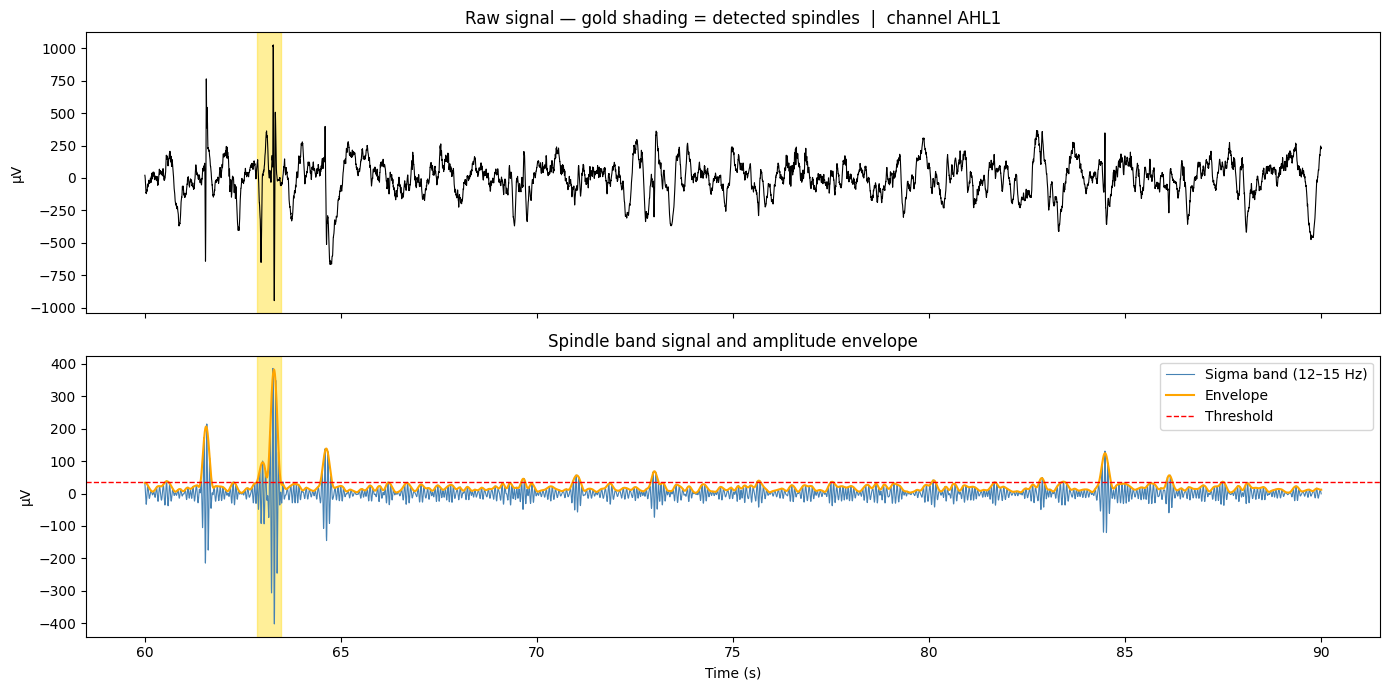

In [13]:
# Plot 30 seconds showing spindles
T_START, T_END = 60, 90
mask = (times >= T_START) & (times <= T_END)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top: raw signal with spindle windows shaded
raw_uv = raw.get_data(picks=[ch_name])[0] * 1e6
axes[0].plot(times[mask], raw_uv[mask], color='black', lw=0.8)
for start, end in spindle_events:
    t_start, t_end = times[start], times[end]
    if t_start >= T_START and t_end <= T_END:
        axes[0].axvspan(t_start, t_end, color='gold', alpha=0.4)
axes[0].set_title(f'Raw signal — gold shading = detected spindles  |  channel {ch_name}')
axes[0].set_ylabel('µV')

# Bottom: sigma-band signal and envelope
axes[1].plot(times[mask], signal_spindle[mask], color='steelblue', lw=0.8, label='Sigma band (12–15 Hz)')
axes[1].plot(times[mask], envelope_smooth[mask], color='orange', lw=1.5, label='Envelope')
axes[1].axhline(spindle_threshold, color='red', ls='--', lw=1, label='Threshold')
for start, end in spindle_events:
    t_start, t_end = times[start], times[end]
    if t_start >= T_START and t_end <= T_END:
        axes[1].axvspan(t_start, t_end, color='gold', alpha=0.4)
axes[1].set_title('Spindle band signal and amplitude envelope')
axes[1].set_ylabel('µV')
axes[1].set_xlabel('Time (s)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## Comparing slow waves and spindles across channels

One of the most interesting questions in sleep neuroscience is whether slow waves and spindles occur simultaneously across the whole brain, or whether they are **local** events happening in different brain regions at different times.

iEEG is uniquely positioned to answer this — we have multiple independent recording sites. Let's count slow waves and spindles across channels and see if some regions are more active than others.

In [14]:
# Count slow waves per channel
def count_slow_waves(raw, ch, fs, threshold_pct=75):
    sig = raw.copy().filter(0.5, 2.0, verbose=False).get_data(picks=[ch])[0] * 1e6
    thresh = np.percentile(np.abs(sig), threshold_pct)
    peaks, _ = find_peaks(-sig, height=thresh, distance=int(0.5 * fs))
    return len(peaks)

channels_to_check = good_chs[:12]  # first 12 good channels

sw_counts = []
for ch in channels_to_check:
    n = count_slow_waves(raw, ch, fs)
    sw_counts.append(n)
    print(f"  {ch}: {n} slow waves")

  AHL1: 180 slow waves
  AHL2: 152 slow waves
  AHL3: 158 slow waves
  AHL4: 161 slow waves
  AHL5: 150 slow waves
  AHL6: 148 slow waves
  AHL7: 161 slow waves
  AHL8: 154 slow waves
  AHR1: 172 slow waves
  AHR2: 154 slow waves
  AHR3: 160 slow waves
  AHR4: 156 slow waves


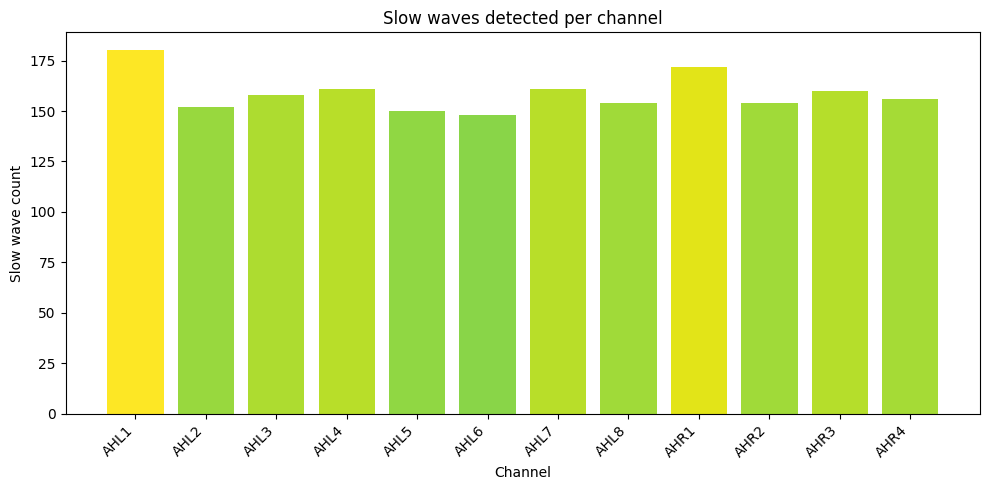

Channels with more slow waves tend to be in cortical regions active during NREM sleep.
Channels with very few may be in subcortical or less 'sleep-active' areas.


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.array(sw_counts) / max(sw_counts))
bars = ax.bar(channels_to_check, sw_counts, color=colors)
ax.set_xlabel('Channel')
ax.set_ylabel('Slow wave count')
ax.set_title('Slow waves detected per channel')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Channels with more slow waves tend to be in cortical regions active during NREM sleep.")
print("Channels with very few may be in subcortical or less 'sleep-active' areas.")

## Summary

NREM sleep is defined by two oscillations that iEEG can capture with remarkable clarity:

- **Slow waves** (0.5–2 Hz): detected by finding large negative peaks in the filtered signal. The down state (negative trough) represents a brief period of cortical silence.
- **Sleep spindles** (12–15 Hz): detected by thresholding the amplitude envelope of the sigma-filtered signal. They are brief waxing-and-waning bursts.

iEEG reveals that both oscillations are **spatially heterogeneous** — they do not always occur simultaneously across the whole brain. This local organisation is invisible to scalp EEG and is one of the core scientific contributions of iEEG sleep research.